In [7]:
from pathlib import Path

dataset_path = Path("RAS-Compound-character-dataset")

for split in dataset_path.iterdir():
    if split.is_dir():
        print(split)
        print(list(split.iterdir())[:5])

RAS-Compound-character-dataset/test
[PosixPath('RAS-Compound-character-dataset/test/61'), PosixPath('RAS-Compound-character-dataset/test/95'), PosixPath('RAS-Compound-character-dataset/test/59'), PosixPath('RAS-Compound-character-dataset/test/92'), PosixPath('RAS-Compound-character-dataset/test/66')]
RAS-Compound-character-dataset/train
[PosixPath('RAS-Compound-character-dataset/train/61'), PosixPath('RAS-Compound-character-dataset/train/95'), PosixPath('RAS-Compound-character-dataset/train/59'), PosixPath('RAS-Compound-character-dataset/train/92'), PosixPath('RAS-Compound-character-dataset/train/66')]


In [8]:
train_path = dataset_path / "train"

class_dirs = [d for d in train_path.iterdir() if d.is_dir()]

print("Number of classes:", len(class_dirs))

for cls in sorted(class_dirs)[:5]:
    imgs = list(cls.glob("*.png"))
    print(cls.name, len(imgs))

Number of classes: 119
1 58
10 62
100 63
101 63
102 60


Matplotlib is building the font cache; this may take a moment.


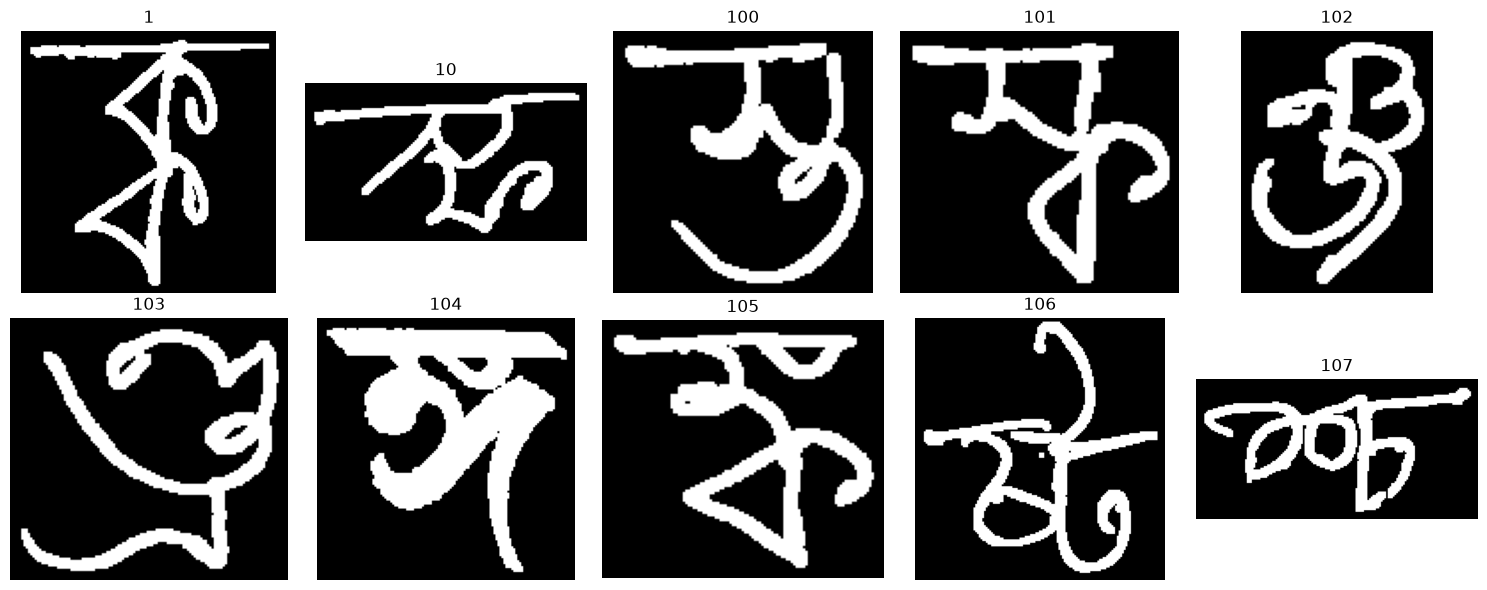

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

train_path = dataset_path / "train"
class_dirs = sorted([d for d in train_path.iterdir() if d.is_dir()])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, cls in zip(axes.flat, class_dirs[:10]):
    imgs = list(cls.glob("*.png"))

    if imgs:
        img = Image.open(imgs[0]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(cls.name)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

IMG_SIZE = 224  # ViT standard input size
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # ViT expects 3 channels
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets for train and test splits separately
train_full_dataset = datasets.ImageFolder(root=str(dataset_path / "train"), transform=train_transforms)
test_dataset = datasets.ImageFolder(root=str(dataset_path / "test"), transform=val_transforms)

class_names = train_full_dataset.classes
NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")
print(f"Total samples in training set: {len(train_full_dataset)}")
print(f"Total samples in test set: {len(test_dataset)}")

# Split training set into train and validation (80% train, 10% val from original training data)
total_train = len(train_full_dataset)
train_size = int(0.9 * total_train) # 90% of original train for new train + val
val_size = total_train - train_size

train_data, val_data = random_split(
    train_full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_dataset)}")

Classes: 119
Total samples in training set: 7020
Total samples in test set: 816
Train: 6318 | Val: 702 | Test: 816


In [6]:
import pandas as pd

mapping_df = pd.read_csv("/class_mapping.csv")
id_to_char = dict(zip(mapping_df["class_id"].astype(str), mapping_df["bengali_character"]))
display_names = [id_to_char[c] for c in class_names]

ModuleNotFoundError: No module named 'pandas'

In [8]:
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class BengaliViT(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Load pretrained ViT-Base/16 (ImageNet pretrained)
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=pretrained,
            num_classes=0  # remove classification head
        )
        embed_dim = self.vit.embed_dim  # 768 for ViT-Base

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=0.3),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)    # [B, 768]
        return self.classifier(features)

model = BengaliViT(num_classes=NUM_CLASSES, pretrained=True).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Model parameters: 86,254,967


In [18]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Fixed: ResNet18 has `model.fc` not `model.vit` ──
optimizer = AdamW([
    {"params": list(model.parameters())[:-2], "lr": LR * 0.1},  # backbone (lower LR)
    {"params": model.fc.parameters(),         "lr": LR}          # head (higher LR)
], weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("Optimizer ready ✓")
print(f"Backbone LR : {LR * 0.1}")
print(f"Head LR     : {LR}")

Optimizer ready ✓
Backbone LR : 2.9999999999999997e-05
Head LR     : 0.0003


In [22]:
import torch
import torchvision.models as models

# Force CPU — avoids the CUDA kernel mismatch error
device = torch.device("cpu")
print("Using device:", device)

# Use ResNet18 instead of ViT — much lighter, works on CPU
model = models.resnet18(weights="IMAGENET1K_V1")

# Replace final layer with your number of classes
model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 10

Using device: cpu


In [25]:
import time
from copy import deepcopy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

# --- Main training ---
best_val_acc = 0.0
best_model_wts = None
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_model_wts = deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_bengali_vit.pth")

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} | "
          f"Time: {time.time()-t0:.1f}s | Best Val: {best_val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch [01/10] Train Loss: 0.0525 Acc: 0.9865 | Val Loss: 0.0570 Acc: 0.9858 | Time: 489.5s | Best Val: 0.9858
Epoch [02/10] Train Loss: 0.0429 Acc: 0.9889 | Val Loss: 0.0788 Acc: 0.9815 | Time: 487.7s | Best Val: 0.9858
Epoch [03/10] Train Loss: 0.0471 Acc: 0.9856 | Val Loss: 0.0466 Acc: 0.9858 | Time: 488.5s | Best Val: 0.9858
Epoch [04/10] Train Loss: 0.0108 Acc: 0.9983 | Val Loss: 0.0218 Acc: 0.9957 | Time: 490.1s | Best Val: 0.9957
Epoch [05/10] Train Loss: 0.0076 Acc: 0.9981 | Val Loss: 0.0495 Acc: 0.9886 | Time: 488.6s | Best Val: 0.9957
Epoch [06/10] Train Loss: 0.0065 Acc: 0.9979 | Val Loss: 0.0244 Acc: 0.9929 | Time: 493.1s | Best Val: 0.9957
Epoch [07/10] Train Loss: 0.0032 Acc: 0.9994 | Val Loss: 0.0332 Acc: 0.9915 | Time: 488.4s | Best Val: 0.9957
Epoch [08/10] Train Loss: 0.0034 Acc: 0.9994 | Val Loss: 0.0156 Acc: 0.9943 | Time: 488.1s | Best Val: 0.9957
Epoch [09/10] Train Loss: 0.0008 Acc: 1.0000 | Val Loss: 0.0073 Acc: 0.9972 | Time: 488.2s | Best Val: 0.9972
Epoch [10/

Test Accuracy: 1.0000
CER          : 0.0000

              precision    recall  f1-score   support

         ক্ক       1.00      1.00      1.00         7
         ক্ষ       1.00      1.00      1.00         7
         ব্ব       1.00      1.00      1.00         7
         ব্য       1.00      1.00      1.00         7
         ব্র       1.00      1.00      1.00         7
         ব্ল       1.00      1.00      1.00         7
         ভ্র       1.00      1.00      1.00         7
         ম্ন       1.00      1.00      1.00         7
         ম্ব       1.00      1.00      1.00         7
         ম্ভ       1.00      1.00      1.00         7
         ম্ম       1.00      1.00      1.00         7
         ম্য       1.00      1.00      1.00         7
         ক্স       1.00      1.00      1.00         7
         ম্র       1.00      1.00      1.00         7
         ম্ল       1.00      1.00      1.00         7
         ল্ক       1.00      1.00      1.00         7
         ল্গ       1.00      1.00   

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2487 (\N{BENGALI LETTER SSA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-p

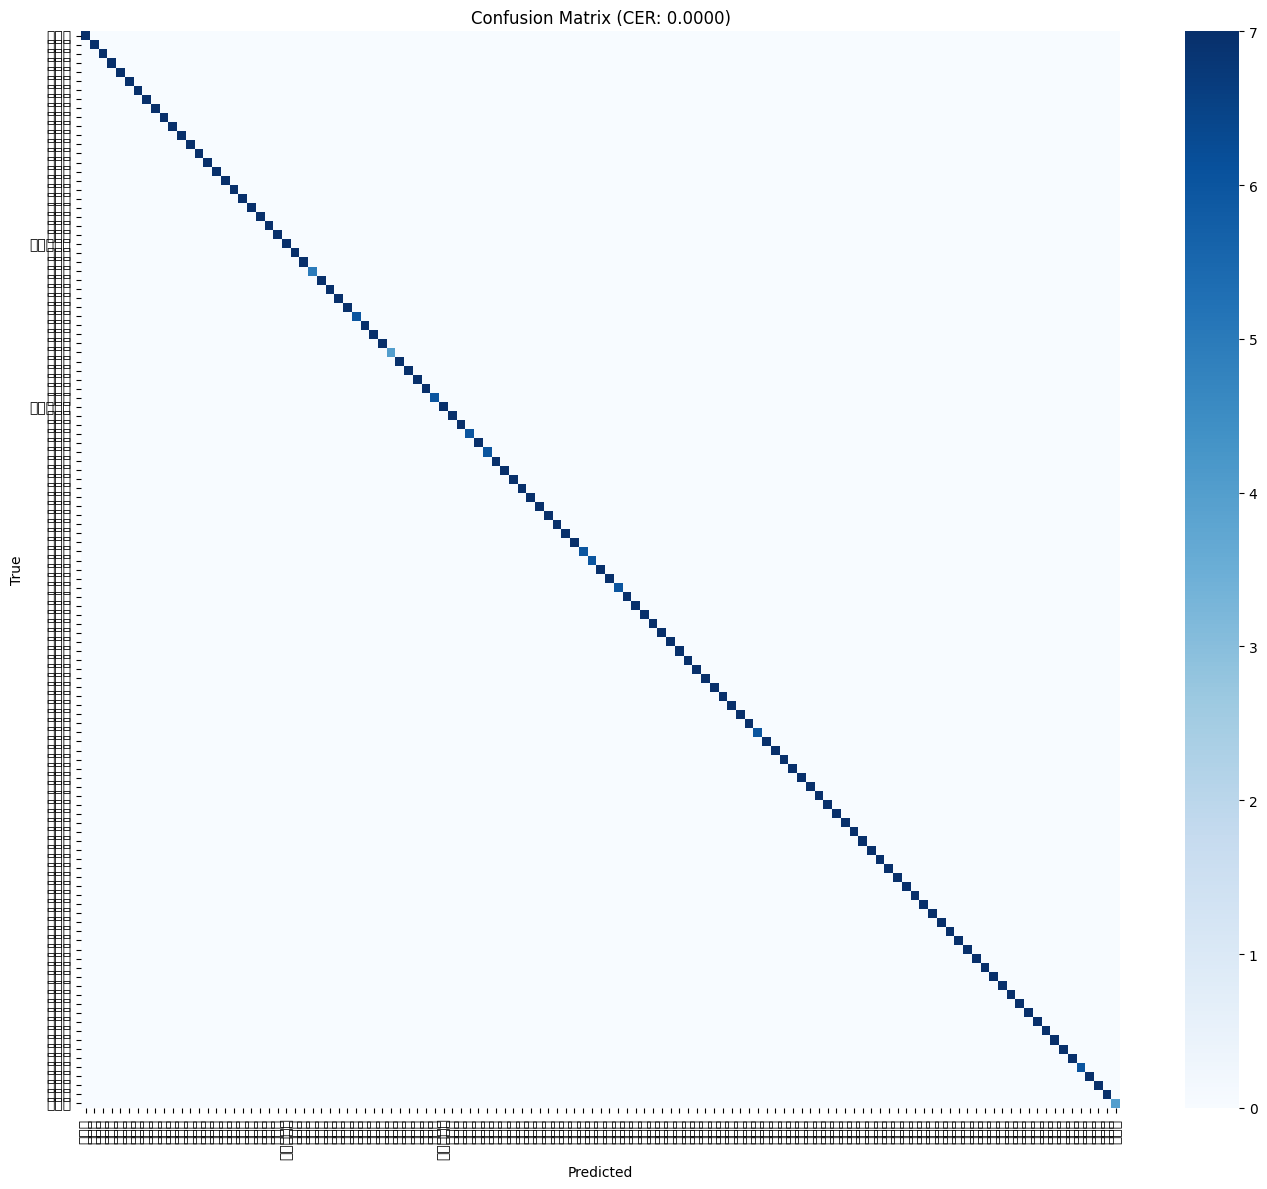

In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(best_model_wts)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())

y_true, y_pred = np.array(y_true), np.array(y_pred)
test_acc = (y_true == y_pred).mean()
cer = 1 - test_acc  # single-character samples: CER == top-1 error rate
print(f"Test Accuracy: {test_acc:.4f}")
print(f"CER          : {cer:.4f}\n")
print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=display_names, yticklabels=display_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (CER: {cer:.4f})")
plt.tight_layout()
plt.show()

In [27]:
torch.save({
    "state_dict": best_model_wts,
    "class_names": class_names,
    "display_names": display_names,
    "img_size": IMG_SIZE,
}, "best_bengali_vit.pth")
print("Saved best_bengali_vit.pth (state_dict + class_names + display_names + img_size)")

Saved best_bengali_vit.pth (state_dict + class_names + display_names + img_size)
